<a href="https://colab.research.google.com/github/estyaprnm/Analisis-Deret-waktu/blob/main/praktikum%20minggu%20kedua.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Kecenderungan Linear

Deret dikatakan memiliki kecenderungan linear dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t$

Berikut simulasi deret yang memiliki kecenderungan linear dalam waktu.

#Asumsi dari regresi

normal,homogen,saling bebas (tidak terjadi autokorelasi),acak, linear.
maksud dari linear ini adalah konstan naik atau kosntan turun jadinya gak beraturan makanya acak

ada pola siklik atau berulang(musiman) ini adalah pola teratur artinya dia berulang di waktu tertentu contohnnya kanyak curah hujan

kalau trend itu pola nya naik terus atau turun terus

Kalau multivariate itu ada X nya, KALAU GAK ADA X NYA BERARTI UNIVARIATE

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

In [5]:
# membangkitkan data waktu dalam bentuk array (misalnya, 100 bulan)
np.random.seed(1058) #NIM saya M0501251058
n=100
t = np.arange(n)

# Membuat deret dengan kecenderungan linear
beta1 = 58.5   # 0.5 + 58
beta0 = 68  # 10 + 58
deret = beta0 + beta1*t

# Menambahkan ingar acak
noise = np.random.normal(scale=2, size=n)  # Noise dengan standar deviasi 2
time_series = deret + noise  # Menggabungkan tren dengan noise

# Membuat DataFrame untuk menyimpan data
df = pd.DataFrame({"Time": pd.date_range(start="2017-01-01", periods=100, freq="M"),
                   "Value": time_series})


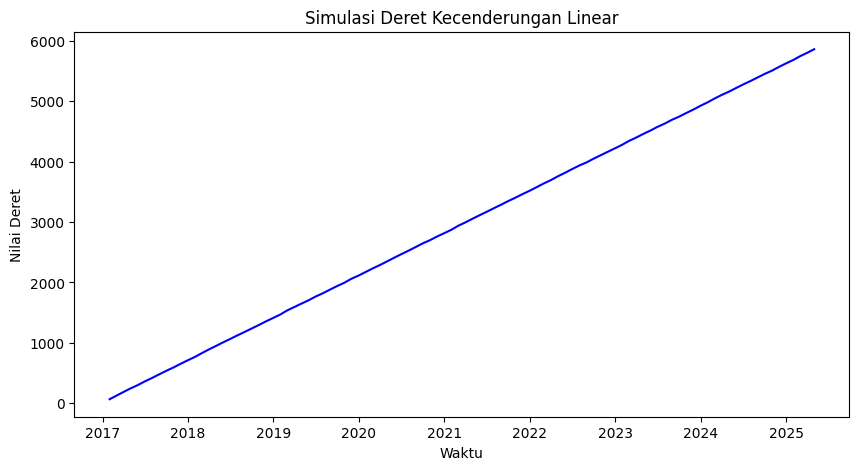

In [26]:
# Plot deret waktu dengan tren linear
plt.figure(figsize=(10, 5))
plt.plot(df["Time"], df["Value"], color="b")
plt.xlabel("Waktu")
plt.ylabel("Nilai Deret")
plt.title("Simulasi Deret Kecenderungan Linear")
plt.show()

**Cek apakah ada korelasi antar pengamatan?**

Berdasarkan hasil simulasi, deret waktu menunjukkan adanya korelasi positif antar pengamatan karena nilai meningkat secara konsisten mengikuti perubahan waktu. Hal ini menunjukkan adanya ketergantungan antar periode yang dipengaruhi oleh komponen tren.

Nilai β₁ (koefisien tren) sangat memengaruhi pola grafik.nilai β₁ menunjukkan besarnya perubahan nilai deret setiap terjadi peningkatan waktu. Ketika β₁ bernilai kecil, pola data masih menunjukkan variasi akibat noise sehingga tren terlihat lebih landai. Sebaliknya, ketika β₁ diperbesar, tren menjadi semakin dominan sehingga grafik menunjukkan pola kenaikan yang lebih lurus dan stabil. Hal ini menunjukkan bahwa semakin besar nilai β₁, semakin kuat pengaruh tren linear terhadap data dan semakin kecil pengaruh fluktuasi acak.


In [7]:
# Konversi kolom Time menjadi angka (misalnya jumlah bulan sejak periode pertama)
df["Time_Numeric"] = (df["Time"].dt.to_period("M") - df["Time"].dt.to_period("M").min()).apply(lambda x: x.n)

# Hitung korelasi antara Time_Numeric dan Value
correlation = df["Time_Numeric"].corr(df["Value"])

print(f"Nilai korelasi antara Time dan Value: {correlation:.4f}")

Nilai korelasi antara Time dan Value: 1.0000


In [8]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = df["Time_Numeric"]
Y = df["Value"]

#memanggil package statsmodels
import statsmodels.api as sm

# Tambahkan konstanta (intercept) ke model regresi
X = sm.add_constant(X)

# Buat dan jalankan model regresi
model = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 6.243e+07
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          3.17e-286
Time:                        14:18:19   Log-Likelihood:                -216.81
No. Observations:                 100   AIC:                             437.6
Df Residuals:                      98   BIC:                             442.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           68.6845      0.424    161.928   

**Bagaimana hasil pengepasan model regresi dibandingkan dengan nilai
parameter asli?**

Hasil estimasi regresi sangat mendekati nilai parameter asli. Parameter awal yang digunakan adalah β₀ = 68 dan β₁ = 58,5, sedangkan hasil regresi menghasilkan β₀ = 68,6845 dan β₁ = 58,4887. Perbedaan nilai yang kecil menunjukkan bahwa model regresi mampu mengestimasi parameter asli dengan baik.

**Apakah model regresi yang dipaskan sudah bagus?**
Model regresi yang dipaskan sudah sangat baik, ditunjukkan oleh nilai R-squared = 1,000, yang berarti hampir seluruh variasi data dapat dijelaskan oleh hubungan linear dengan waktu. Selain itu, nilai p-value koefisien β₁ < 0,05 menunjukkan bahwa tren waktu berpengaruh signifikan terhadap nilai deret. Dengan demikian, model regresi linear sudah mampu menggambarkan pola data secara akurat.



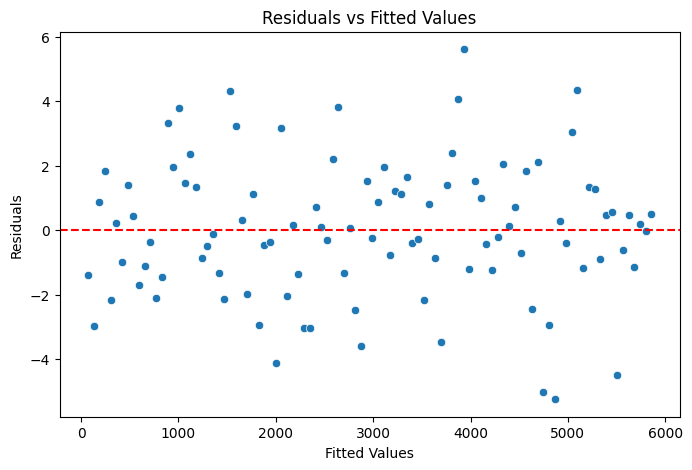

In [9]:
# Analisis Sisaan Model
import seaborn as sns

# Plot Residuals vs. Fitted Values
plt.figure(figsize=(8,5))
sns.scatterplot(x=model.fittedvalues, y=model.resid)
plt.axhline(y=0, color="r", linestyle="--")
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Apa interpretasi dari plot tersebut?**

Plot menunjukkan bahwa residual tersebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini mengindikasikan bahwa asumsi linearitas model terpenuhi dan tidak terdapat pola sistematis pada kesalahan prediksi.

Selain itu, penyebaran residual relatif konstan pada berbagai nilai fitted values, sehingga tidak menunjukkan adanya masalah heteroskedastisitas. Dengan demikian, model regresi dapat dikatakan sudah cukup baik dalam menjelaskan hubungan antara waktu dan nilai deret.

In [10]:
from statsmodels.stats.diagnostic import het_breuschpagan

# Uji Breusch-Pagan
bp_test = het_breuschpagan(model.resid, model.model.exog)

print(f"P-value Breusch-Pagan Test: {bp_test[1]:.4f}")


P-value Breusch-Pagan Test: 0.5430


**Apa kesimpulan dari nilai uji Breusch Pagan tersebut?**

Hasil uji Breusch-Pagan menunjukkan nilai p-value = 0,5430. Karena nilai p-value lebih besar dari tingkat signifikansi α = 0,05, maka gagal menolak H₀.

Artinya, tidak terdapat bukti adanya masalah heteroskedastisitas pada residual model. Varians residual dapat dianggap konstan (homoskedastis), sehingga asumsi regresi linear terkait kesamaan varians error telah terpenuhi. Dengan demikian, model regresi yang digunakan sudah layak.

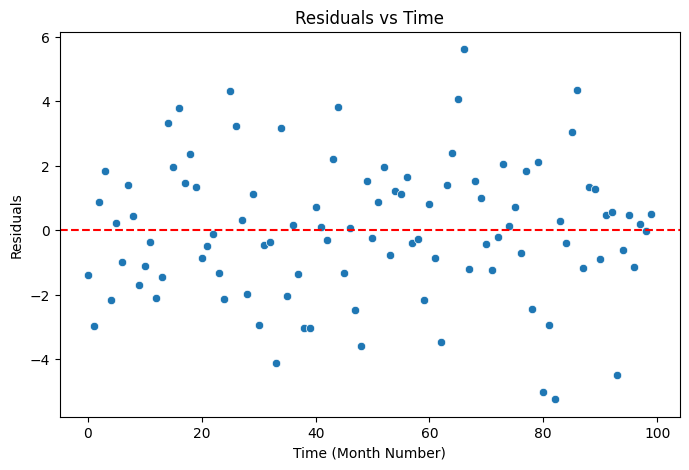

In [11]:
# Plot residual vs time
plt.figure(figsize=(8,5))
sns.scatterplot(x=df["Time_Numeric"], y=model.resid)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Time (Month Number)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


<Figure size 800x500 with 0 Axes>

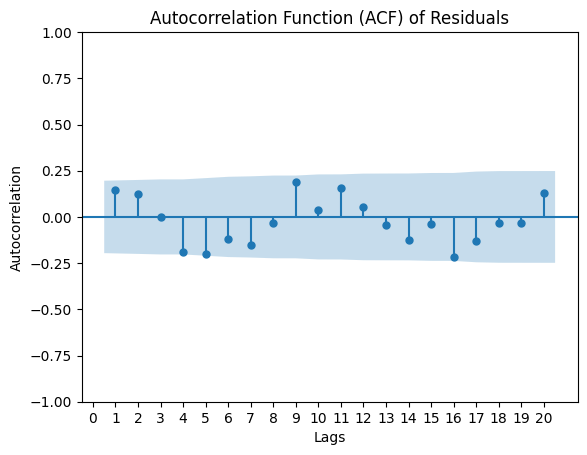

In [12]:
from statsmodels.graphics.tsaplots import plot_acf

# Plot Autocorrelation Function (ACF)
plt.figure(figsize=(8, 5))
plot_acf(model.resid, lags=20, zero=False)
plt.xticks(ticks=range(0, 21, 1))
plt.title("Autocorrelation Function (ACF) of Residuals")
plt.xlabel("Lags")
plt.ylabel("Autocorrelation")
plt.show()


**Apa yang dapat Anda simpulkan dari plot di atas?**

Berdasarkan plot ACF residual, sebagian besar nilai autokorelasi pada setiap lag berada di dalam batas interval kepercayaan. Hal ini menunjukkan bahwa tidak terdapat autokorelasi yang signifikan pada residual.

Dengan demikian, residual dapat dianggap bersifat acak (independen antar waktu), sehingga asumsi independensi error pada model regresi telah terpenuhi. Model regresi yang digunakan sudah cukup baik dalam menangkap pola data tanpa menyisakan pola ketergantungan waktu.

In [13]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Uji Ljung-Box untuk autokorelasi residual
ljung_box_test = acorr_ljungbox(model.resid, lags=range(1,20), return_df=True)

print("Ljung-Box Test p-value:")
print(ljung_box_test)


Ljung-Box Test p-value:
      lb_stat  lb_pvalue
1    2.186097   0.139262
2    3.823144   0.147848
3    3.823158   0.281204
4    7.746874   0.101303
5   12.049106   0.034121
6   13.631529   0.034034
7   16.217506   0.023202
8   16.330031   0.037893
9   20.319632   0.016039
10  20.470251   0.025106
11  23.322196   0.015914
12  23.626439   0.022855
13  23.826202   0.032767
14  25.747549   0.027866
15  25.922398   0.038846
16  31.641354   0.011131
17  33.675862   0.009243
18  33.822333   0.013247
19  33.956796   0.018594


**Apa kesimpulan dari hasil uji Ljung-Box tersebut?**

Berdasarkan hasil uji Ljung-Box, beberapa lag memiliki nilai p-value < 0,05, terutama mulai dari lag ke-5 hingga lag ke-19. Hal ini menunjukkan bahwa H₀ ditolak, sehingga terdapat indikasi adanya autokorelasi pada residual.

Artinya, residual model belum sepenuhnya bersifat acak dan masih terdapat pola ketergantungan antar waktu yang belum dijelaskan oleh model regresi. Dengan demikian, meskipun sebagian kecil lag awal tidak menunjukkan autokorelasi signifikan, secara keseluruhan model masih menyisakan korelasi temporal pada residual sehingga perlu dilakukan evaluasi atau pengembangan model lebih lanjut.

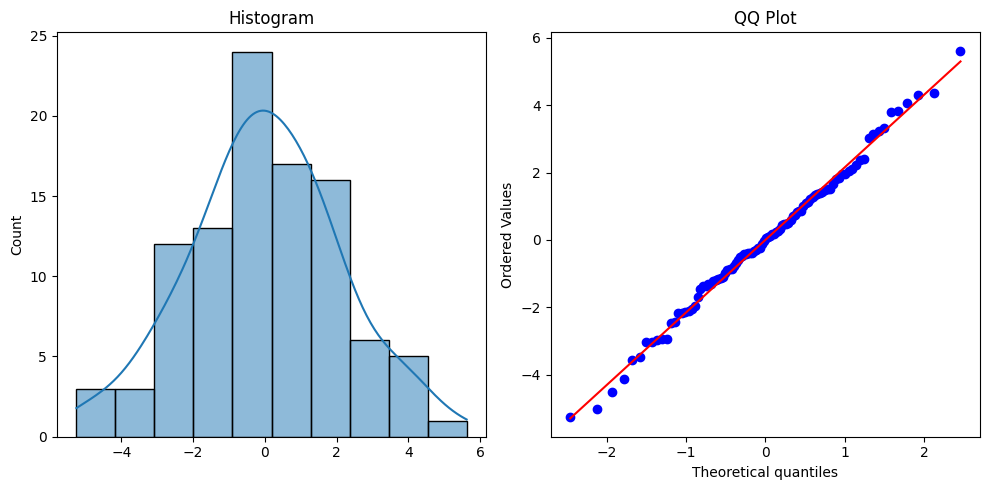

In [14]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(model.resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(model.resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Apa kesimpulan Anda berdasarkan plot di atas?**

Berdasarkan histogram residual, pola distribusi residual terlihat mendekati distribusi normal dengan bentuk menyerupai kurva lonceng dan terpusat di sekitar nilai nol. Hal ini didukung oleh QQ Plot, di mana sebagian besar titik mengikuti garis diagonal.

Dengan demikian, residual dapat dianggap berdistribusi normal, sehingga asumsi normalitas pada model regresi telah terpenuhi.

In [15]:
# Uji Shapiro-Wilk
shapiro_stat, shapiro_p_value = stats.shapiro(model.resid)
print(f"Shapiro-Wilk Test: Statistics = {shapiro_stat}, p-value = {shapiro_p_value}")

Shapiro-Wilk Test: Statistics = 0.9942433812259206, p-value = 0.9505380764047506


**Apakah kesimpulan Anda dari nilai uji Shapiro Wilk sama dengan kesimpulan
Anda berdasarkan plot?**

Ya, hasil uji Shapiro-Wilk konsisten dengan kesimpulan berdasarkan plot. Nilai p-value = 0,9505 > 0,05, sehingga gagal menolak H₀ yang berarti residual berdistribusi normal.

Hasil ini sesuai dengan histogram dan QQ Plot yang menunjukkan bahwa residual mengikuti pola distribusi normal. Dengan demikian, asumsi normalitas residual pada model regresi telah terpenuhi.

## Kecenderungan Kuadratik

Deret dikatakan memiliki kecenderungan kuadratik dalam waktu jika $\mu_t$ dapat dinyatakan sebagai:

$\mu_t=\beta_0+\beta_1t+\beta_2t^2$


In [17]:
# Menentukan parameter simulasi
np.random.seed(1058)
n_periods = 120
beta_0, beta_1, beta_2= 108, 58.5, 58.02 #nim M0501251058)
noise = np.random.normal(0, 10, n_periods)
time = np.arange(n_periods)

# Membuat komponen kuadratik
quadratic_component = beta_0 + beta_1 * time + beta_2 * time**2

# Menambahkan noise untuk membuat data lebih realistis
data = quadratic_component + noise

# Membuat DataFrame
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')
df_quad = pd.DataFrame({'Date': dates, 'Value': data})

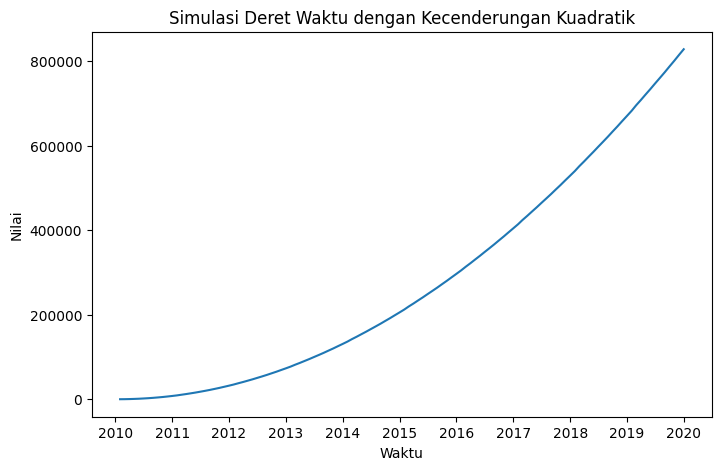

In [18]:
# Plot hasil simulasi deret waktu dengan kecenderungan kuadratik
plt.figure(figsize=(8, 5))
plt.plot(df_quad.Date, df_quad['Value'])
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.show()

**Apa interpretasi Anda terhadap deret? Apa perbedaan pola yang terlihat dalam deret dibandingkan plot deret pada pola kecenderungan linear?**

Berdasarkan grafik, deret waktu menunjukkan adanya kecenderungan kuadratik positif, di mana nilai deret meningkat dengan laju pertumbuhan yang semakin besar seiring bertambahnya waktu. Hal ini ditunjukkan oleh bentuk kurva yang semakin menanjak akibat adanya pengaruh komponen kuadratik $(t^2)$.

Dibandingkan dengan kecenderungan linear, pola kuadratik memiliki perubahan laju pertumbuhan yang tidak konstan. Pada pola linear, peningkatan nilai terjadi secara tetap sehingga membentuk garis lurus, sedangkan pada pola kuadratik peningkatan semakin cepat sehingga menghasilkan pola melengkung ke atas.

In [19]:
# Mendefinisikan variabel independen (X) dan dependen (Y)
X = np.column_stack((time, time**2))
X = sm.add_constant(X)
Y = data


# Buat dan jalankan model regresi
model_quad = sm.OLS(Y, X).fit()

# menampilkan ringkasan hasil regresi
print(model_quad.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 3.113e+10
Date:                Fri, 04 Sep 2026   Prob (F-statistic):               0.00
Time:                        14:40:36   Log-Likelihood:                -455.80
No. Observations:                 120   AIC:                             917.6
Df Residuals:                     117   BIC:                             926.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        111.5008      2.946     37.852      0.0

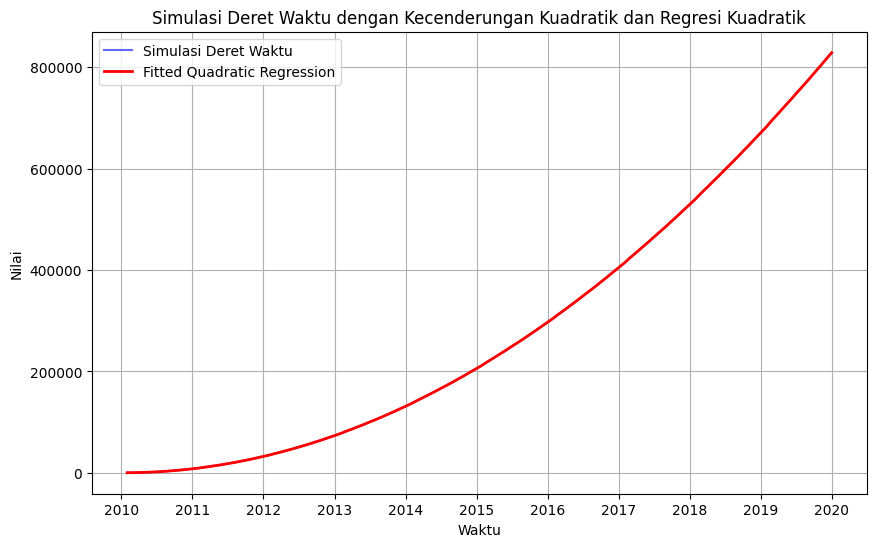

In [20]:
# Prediksi menggunakan model yang sudah dilatih
data_pred = model_quad.predict(X)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(df_quad.Date, df_quad['Value'], label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(df_quad.Date, data_pred, label='Fitted Quadratic Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Kuadratik dan Regresi Kuadratik')
plt.xlabel('Waktu')
plt.ylabel('Nilai')
plt.legend()
plt.grid(True)
plt.show()

**Cek apakah model regresi kuadratik yang dipaskan terhadap sudah memenuhi asumsi-asumsi model!**

Berdasarkan grafik hasil pemodelan, regresi kuadratik mampu mengikuti pola data dengan baik. Kurva hasil fitting terlihat hampir berimpit dengan deret waktu simulasi, yang menunjukkan bahwa model mampu menangkap pola kecenderungan kuadratik pada data.

Namun, untuk memastikan seluruh asumsi regresi terpenuhi, perlu dilakukan pemeriksaan lebih lanjut terhadap residual, seperti uji normalitas residual, uji heteroskedastisitas, dan uji autokorelasi. Dari grafik ini saja dapat disimpulkan bahwa asumsi kesesuaian bentuk model terhadap pola tren sudah terpenuhi.

**Apakah model yang dipaskan terhadap deret sudah tepat? Jelaskan jawaban Anda!**

Model regresi kuadratik yang dipaskan sudah tepat, karena bentuk kurva hasil prediksi mengikuti pola peningkatan data yang melengkung ke atas. Hal ini menunjukkan bahwa model kuadratik mampu menjelaskan perubahan nilai deret yang semakin meningkat seiring waktu.

Dengan demikian, penggunaan model regresi kuadratik lebih sesuai dibandingkan model linear untuk deret yang memiliki pola pertumbuhan yang semakin cepat.

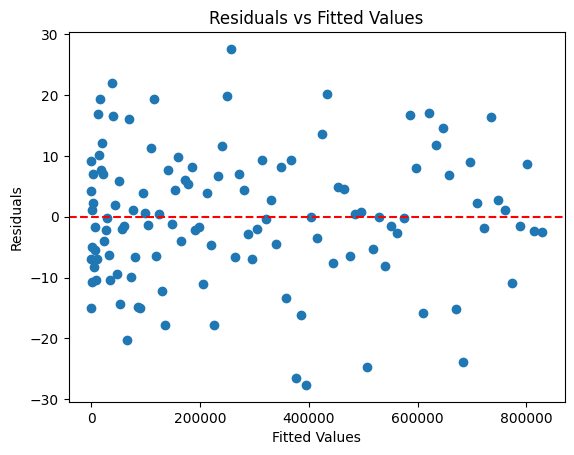

In [21]:
#cek asumsi model regresi kuadratik
# Residual model regresi kuadratik
residuals = model_quad.resid

# 1. Plot residual vs fitted values
import matplotlib.pyplot as plt

fitted = model_quad.fittedvalues

plt.scatter(fitted, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted Values")
plt.show()


**Interpretasi Plot residual**

Berdasarkan plot, residual terlihat menyebar secara acak di sekitar garis nol tanpa membentuk pola tertentu. Hal ini menunjukkan bahwa model regresi kuadratik sudah mampu menangkap pola tren pada data dengan baik.

Selain itu, penyebaran residual relatif stabil pada berbagai nilai fitted values, sehingga tidak terlihat adanya indikasi kuat heteroskedastisitas. Dengan demikian, asumsi bahwa error memiliki varians yang relatif konstan dapat dianggap terpenuhi dan model regresi kuadratik cukup sesuai untuk menjelaskan pola data.

In [22]:
#Uji Heteroskedastisitas (Breusch-Pagan)

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(residuals, model_quad.model.exog)

print("P-value Breusch-Pagan:", bp_test[1])

P-value Breusch-Pagan: 0.4948569930175598


**interpretasi uji heteroskedastisitas**

Hasil uji Breusch-Pagan menunjukkan nilai p-value = 0,4949. Karena nilai tersebut lebih besar dari tingkat signifikansi α = 0,05, maka gagal menolak H₀.

Artinya, tidak terdapat indikasi heteroskedastisitas pada residual model regresi kuadratik. Varians residual dapat dianggap konstan (homoskedastis), sehingga asumsi terkait kesamaan varians error pada model regresi telah terpenuhi.

In [23]:
#Uji Autokorelasi Residual (Ljung-Box)
from statsmodels.stats.diagnostic import acorr_ljungbox

ljung_box = acorr_ljungbox(residuals, lags=20, return_df=True)

print(ljung_box)

      lb_stat  lb_pvalue
1    2.616386   0.105765
2    3.058533   0.216695
3    3.062576   0.382077
4    7.455934   0.113668
5   10.421545   0.064135
6   10.897671   0.091591
7   14.780539   0.038918
8   14.896263   0.061194
9   19.559167   0.020837
10  19.779349   0.031410
11  21.742916   0.026442
12  22.260761   0.034699
13  22.506150   0.047999
14  22.807858   0.063469
15  22.901419   0.086255
16  29.317815   0.021879
17  30.026249   0.026156
18  30.117678   0.036318
19  31.086326   0.039501
20  32.828324   0.035233


**interpretasi uji autokorelasi**

Berdasarkan hasil uji Ljung-Box, beberapa nilai p-value berada di bawah 0,05, terutama pada lag ke-7, ke-9 hingga ke-13, serta lag ke-16 sampai ke-20. Hal ini menunjukkan bahwa H₀ ditolak pada beberapa lag, sehingga terdapat indikasi adanya autokorelasi pada residual.

Dengan demikian, residual model regresi kuadratik belum sepenuhnya bersifat acak (independen) karena masih terdapat pola ketergantungan antar waktu pada beberapa lag. Artinya, meskipun model sudah mampu menangkap pola kuadratik utama, masih terdapat informasi temporal yang belum dijelaskan oleh model.

In [24]:
#Uji Normalitas Residual (Shapiro-Wilk)
from scipy import stats

shapiro_test = stats.shapiro(residuals)

print("Statistic:", shapiro_test.statistic)
print("P-value:", shapiro_test.pvalue)

Statistic: 0.9931972051523489
P-value: 0.8287602035464365


**interpretasi uji normalitas**

Hasil uji Shapiro-Wilk menunjukkan nilai statistic = 0,9932 dengan p-value = 0,8288. Karena nilai p-value > 0,05, maka gagal menolak H₀.

Artinya, residual model regresi kuadratik dapat dianggap berdistribusi normal. Dengan demikian, asumsi normalitas residual pada model regresi telah terpenuhi.

**Interpretasi Asumsi Model Regresi Kuadratik:**

Berdasarkan hasil pengujian asumsi, model regresi kuadratik telah memenuhi beberapa asumsi penting. Residual tidak menunjukkan pola tertentu dan tidak terjadi heteroskedastisitas (p-value Breusch-Pagan = 0,4949 > 0,05).

 Selain itu, residual berdistribusi normal berdasarkan uji Shapiro-Wilk (p-value = 0,8288 > 0,05). Namun, uji Ljung-Box menunjukkan adanya autokorelasi pada beberapa lag, sehingga masih terdapat ketergantungan waktu pada residual. Secara umum, model sudah mampu menangkap pola kuadratik, tetapi masih perlu perbaikan untuk mengatasi autokorelasi residual.

## Kecenderungan Musiman/Siklik

Misalkan suatu deret waktu memiliki nilaitengah $\mu_t$ yang didefinisikan sebagai berikut:

$\mu_t=\beta_0+\beta_1 cos(2\pi f t)+\beta_2 sin(2\pi ft)$

Deret tersebut memiliki kecenderungan kosinus yang berpola musiman.

Bentuk lain fungsi nilaitengah dari kecenderungan musiman (misalnya untuk data bulanan) adalah $\mu_t$ berupa suatu konstanta sejumlah 12 yang nilai berbeda-beda. Nilai ini diinterpretasikan sebagai nilai harapan rata-rata data untuk masing-masing bulan, atau dapat dituliskan sebagai berikut:

$\mu_t=\beta_1$ , untuk $t=1,13,25,...$
       
$\mu_t=\beta_2$ , untuk $t=2,14,26,...$

$.$

$.$

$.$

$\mu_t=\beta_{12}$ , $untuk t=12,24,36,...$


In [29]:
# Menentukan parameter simulasi
np.random.seed(1058)
n_periods = 120
beta0, beta1, beta2=108,33, 56
freq=1/12

# Membuat komponen musiman
time = np.arange(n_periods)
seasonal_component = beta0+ beta1*np.cos(2*np.pi*time*freq)+beta2*np.sin(2*np.pi*time*freq)

# Menambahkan noise acak
noise = np.random.normal(0, 2, n_periods)

# Simulasi data dengan hanya komponen musiman dan noise (tanpa tren)
data = seasonal_component + noise

# Membuat index waktu (misalnya menggunakan bulan)
dates = pd.date_range(start='2010-01-01', periods=n_periods, freq='M')

# Membuat DataFrame untuk mempermudah analisis dan visualisasi
df_seasonal = pd.DataFrame({'Date': dates, 'Value': data})


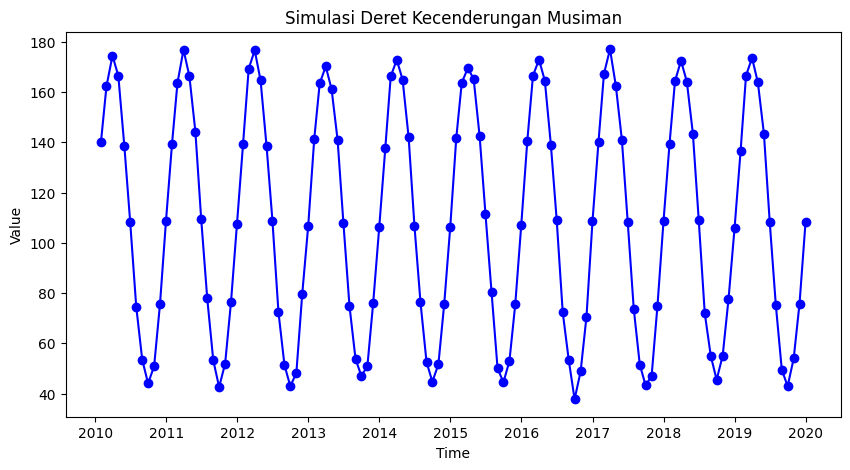

In [30]:
# Plot data deret waktu
plt.figure(figsize=(10, 5))
plt.plot(df_seasonal["Date"], df_seasonal["Value"],'-ob')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title("Simulasi Deret Kecenderungan Musiman")
plt.show()


**Misalkan deret tersebut merupakan deret musiman dengan periode musiman 12. Bagaimana Anda menginterpretasikan pola yang terlihat dalam deret tersebut?**


Berdasarkan grafik, deret waktu menunjukkan pola musiman dengan periode 12 bulan. Hal ini terlihat dari pola naik-turun yang berulang secara konsisten setiap 12 pengamatan. Nilai deret mengalami peningkatan hingga mencapai puncak, kemudian menurun menuju titik terendah, dan pola tersebut kembali berulang pada periode berikutnya.

Deret ini tidak menunjukkan adanya tren naik atau turun dalam jangka panjang, sehingga perubahan nilai utama disebabkan oleh komponen musiman. Fluktuasi yang terjadi relatif stabil dari tahun ke tahun, dengan variasi kecil yang berasal dari noise acak.

In [31]:
# membuat dummy variabel musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
musim= Seasonality(12, initial_period=1).in_sample(df_seasonal.index)
musim.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [32]:
musim

,Januari,Februari,Maret,April,Mei,Juni,Juli,Agustus,September,Oktober,November,Desember
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
115,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
116,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
117,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
118,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [33]:
# pengepasan model regresi tanpa intercept
musiman=sm.OLS(df_seasonal["Value"],musim).fit()

In [34]:
print(musiman.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     5324.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          3.01e-142
Time:                        15:02:01   Log-Likelihood:                -252.25
No. Observations:                 120   AIC:                             528.5
Df Residuals:                     108   BIC:                             561.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari      139.6644      0.660    211.608      0.0

**Bagaimana interpretasi dari hasil tersebut?**

Hasil regresi menunjukkan bahwa model mampu menjelaskan pola musiman dengan sangat baik, ditunjukkan oleh nilai R-squared = 0,998. Artinya, sekitar 99,8% variasi nilai deret waktu dapat dijelaskan oleh faktor musiman bulanan, sedangkan sisanya dipengaruhi oleh komponen lain seperti noise.

Seluruh koefisien bulan memiliki p-value < 0,05, sehingga setiap bulan memberikan pengaruh yang signifikan terhadap pola deret waktu. Nilai tertinggi terjadi pada bulan Maret (173,68), sedangkan nilai terendah terjadi pada bulan September (43,51), yang menunjukkan adanya pola musiman yang kuat sepanjang tahun.

Nilai Durbin-Watson = 1,791 menunjukkan bahwa residual relatif tidak mengalami autokorelasi yang kuat. Selain itu, hasil uji normalitas residual (Jarque-Bera) menunjukkan p-value = 0,557 > 0,05, sehingga residual dapat dianggap berdistribusi normal.

Secara keseluruhan, model regresi musiman sudah sesuai dan mampu menggambarkan pola musiman periode 12 bulan dengan baik.

In [35]:
# Analisis Sisaan
# mendapatkan sisaan terbakukan
influence=musiman.get_influence()
std_resid=influence.resid_studentized_internal

mapping={1:'$J$',2:'$F$',3:'$M$',
 4:'$A$',5:'$M$',6:'$J$',
 7:'$J$',8:'$A$',9:'$S$',
 10:'$O$',11:'$N$',12:'$D$'}

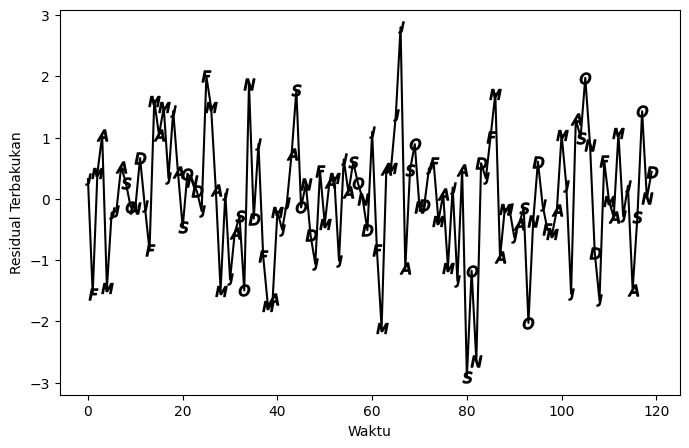

In [37]:
#memetakan sisaan dengan bentuk plot sesuai simbol bulan/musim
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
 plt.plot(i, std_resid[i], marker=mapping[i%12+1],
 color='black', markersize=8)

#membuat plot sisaan terbakukan
plt.plot(std_resid, color='black')
plt.xlabel('Waktu'), plt.ylabel('Residual Terbakukan')
plt.show()


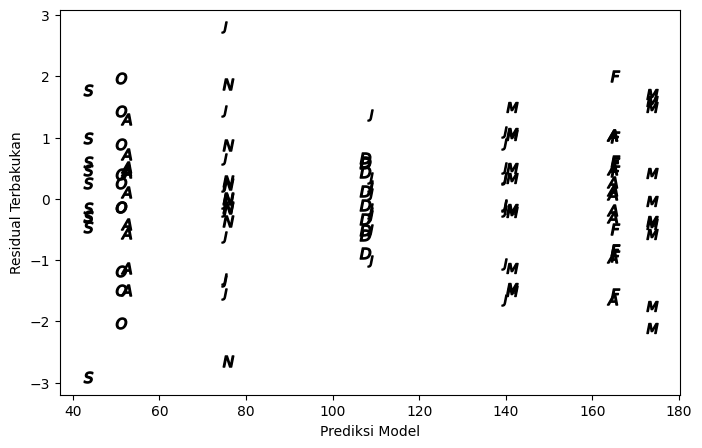

In [38]:
# membuat plot fittedvalues dengan residual terbakukan dengan simbol bulan
plt.figure(figsize=(8,5))
for i in range(len(std_resid)):
  plt.plot(musiman.fittedvalues.values[i],
           std_resid[i], marker=mapping[i%12+1],
           color='black', markersize=8)
plt.xlabel('Prediksi Model'),plt.ylabel('Residual Terbakukan')
plt.show()

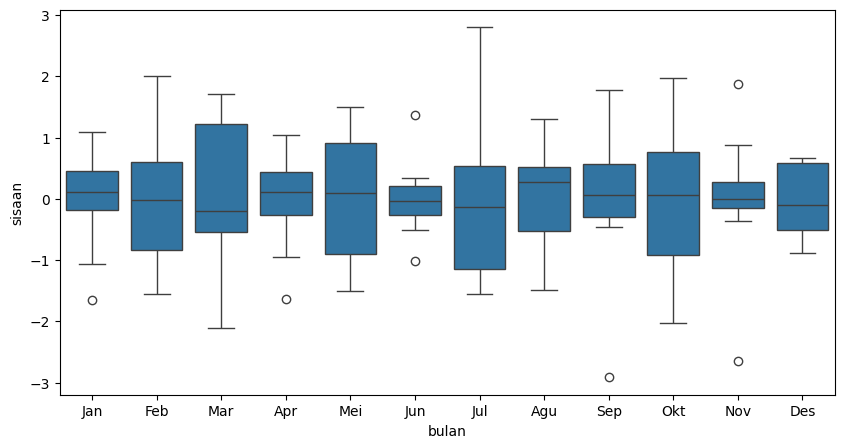

In [39]:
#membuat list daftar bulan
bulan=['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']*10

#membuat dataframe untuk mengidentifikasi sisaan dan periode bulannya
box_sisaan=pd.DataFrame(zip(bulan[:-1], std_resid),
columns=['bulan','sisaan'])

#membuat boxplot per buln
plt.figure(figsize=(10,5))
sns.boxplot(x='bulan',y='sisaan',data=box_sisaan)
plt.show()

**Bagaimana interpretasi Anda terhadap tiga plot di atas?**
1. Plot residual terhadap waktu (Residual Terbukakan vs Waktu)
Plot menunjukkan bahwa residual berfluktuasi di sekitar nilai nol tanpa membentuk pola tren tertentu. Hal ini menunjukkan bahwa model sudah mampu menangkap pola musiman utama pada data, sehingga sisa kesalahan bersifat acak. Namun, masih terdapat beberapa nilai residual yang cukup besar, yang menunjukkan adanya variasi yang belum sepenuhnya dijelaskan oleh model.
2. Plot residual terhadap nilai prediksi model (Residual vs Prediksi Model)
Residual tersebar secara acak pada berbagai nilai prediksi dan tidak membentuk pola tertentu. Hal ini menunjukkan bahwa tidak terdapat indikasi kuat adanya hubungan antara besar prediksi dengan kesalahan model, sehingga asumsi linearitas dan kestabilan varians residual cukup terpenuhi.
3. Boxplot residual berdasarkan bulan
Boxplot menunjukkan bahwa penyebaran residual pada setiap bulan relatif berada di sekitar nilai nol, meskipun terdapat beberapa pencilan (outlier) pada beberapa bulan. Hal ini menunjukkan bahwa variasi kesalahan antar bulan relatif stabil dan tidak terdapat perbedaan pola residual yang besar antar periode musiman.

**Kesimpulan umum:**

Berdasarkan ketiga plot tersebut, model regresi musiman sudah cukup baik dalam menangkap pola musiman data. Residual cenderung acak dan tidak menunjukkan pola sistematis, meskipun masih terdapat beberapa pencilan yang menunjukkan adanya variasi yang tidak dijelaskan oleh model.

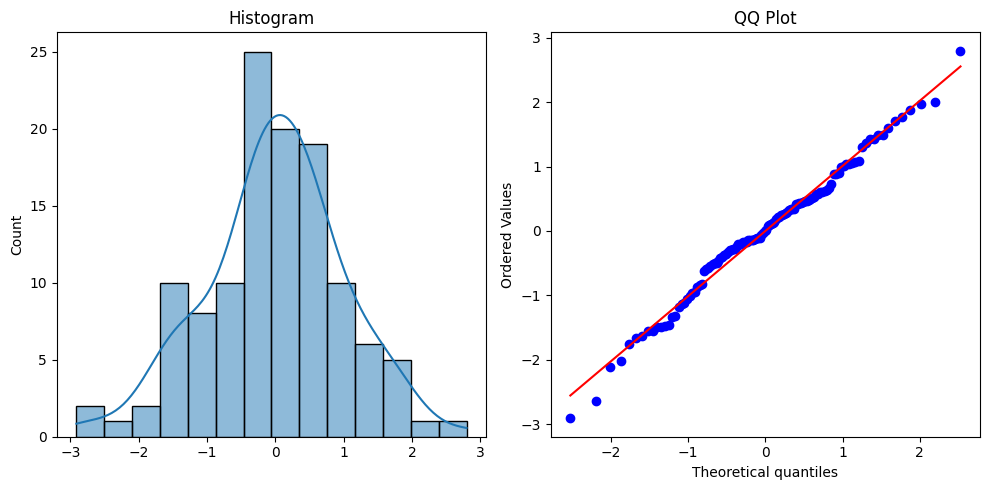

In [40]:
# Histogram Residuals
import scipy.stats as stats
fig, axes = plt.subplots(1, 2, figsize=(10,5))
# Histogram
sns.histplot(std_resid, kde=True, ax=axes[0])
axes[0].set_title('Histogram')

# QQ Plot
stats.probplot(std_resid, dist="norm", plot=axes[1])
axes[1].set_title('QQ Plot')

plt.tight_layout()
plt.show()

**Berdasarkan plot-plot tersebut apakah dapat dikatakan bahwa model yang dipaskan sudah tepat?**

Berdasarkan histogram residual, distribusi residual terlihat mendekati bentuk normal dan terpusat di sekitar nilai nol. Hal ini diperkuat oleh QQ Plot, di mana sebagian besar titik mengikuti garis diagonal, meskipun terdapat sedikit penyimpangan pada bagian ekor.

Dengan demikian, model regresi musiman yang dipaskan dapat dikatakan cukup tepat, karena residual sudah memenuhi asumsi normalitas dan tidak menunjukkan penyimpangan yang besar. Namun, untuk memastikan model benar-benar valid, tetap diperlukan pengujian statistik terhadap residual.

**Hitunglah statistik uji untuk mengecek asumsi model**

Berdasarkan hasil pengujian statistik, residual model telah memenuhi asumsi regresi, yaitu berdistribusi normal, memiliki varians yang konstan, dan tidak mengalami autokorelasi. Dengan demikian, model regresi musiman yang dipasang sudah sesuai untuk menggambarkan pola data.

In [56]:
# Hitung statistik uji untuk mengecek asumsi model tanpa intersep

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm


# Residual dari model tanpa intersep
residuals = musiman.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)

# Tambahkan konstanta hanya untuk kebutuhan uji BP
exog_bp = sm.add_constant(musiman.model.exog)

bp_test = het_breuschpagan(
    residuals,
    exog_bp
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)

ljung_test = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9899876473937163
P-value   : 0.5332295304529971

=== Breusch-Pagan Test ===
LM Statistic : 10.914271310033303
P-value      : 0.5362796234865663

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  11.290376   0.504211


**Kesimpulan Uji Asumsi Model Regresi Musiman Tanpa Intersep:**

Berdasarkan hasil pengujian asumsi model, diperoleh:

Uji Normalitas Residual (Shapiro-Wilk)
1. Uji Normalitas Residual (Shapiro-Wilk)
Hasil uji menunjukkan nilai p-value = 0,5332 > 0,05, sehingga gagal menolak H₀. Artinya, residual model berdistribusi normal.
2. Uji Heteroskedastisitas (Breusch-Pagan)
Hasil uji menunjukkan nilai p-value = 0,5363 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat indikasi heteroskedastisitas dan varians residual dapat dianggap konstan.
3. Uji Autokorelasi (Ljung-Box)
Hasil uji menunjukkan nilai p-value = 0,5042 > 0,05, sehingga gagal menolak H₀. Artinya, tidak terdapat autokorelasi pada residual dan residual bersifat independen.

**Kesimpulan umum:**


Model regresi musiman tanpa intersep telah memenuhi asumsi utama regresi, yaitu residual berdistribusi normal, memiliki varians yang konstan, dan tidak mengalami autokorelasi. Dengan demikian, model yang dipaskan sudah cukup baik dalam menggambarkan pola musiman pada deret waktu.

In [51]:
# pengepasan model regresi dengan intersep
musiman_int=sm.OLS(df_seasonal["Value"],sm.add_constant(musim.iloc[:,1:])).fit()

In [52]:
print(musiman_int.summary())

                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                     5324.
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          3.01e-142
Time:                        15:51:44   Log-Likelihood:                -252.25
No. Observations:                 120   AIC:                             528.5
Df Residuals:                     108   BIC:                             561.9
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        139.6644      0.660    211.608      0.0

**Perhatikan hasil pengepasan model dengan intersep. Bandingkan hasilnya dengan pengepasan tanpa intersep. Bagaimana interpretasi model dengan intersep dibandingkan model tanpa intersep? Jelaskan cara memaknai nilai koefisien regresi yang diperoleh!**

Model dengan intersep dapat dituliskan sebagai:

$$ Y_t = \beta_0 + \beta_1X_1+\beta_2X_2+...+\beta_{12}X_{12}+e_t $$

dengan nilai intersep (\(\beta_0\)) = 139,6644 sebagai nilai dasar deret. Koefisien bulan menunjukkan perubahan nilai dibandingkan bulan Januari sebagai acuan. Contohnya, koefisien Februari 25,6696 berarti nilai Februari lebih tinggi 25,67 dibanding Januari, sedangkan September -96,1512 berarti lebih rendah 96,15 dibanding Januari.

Pada model tanpa intersep, persamaan menjadi:

$$ Y_t=\beta_1X_1+\beta_2X_2+...+\beta_{12}X_{12}+e_t $$

sehingga koefisien langsung menggambarkan nilai masing-masing bulan.


**Apakah model dengan intersep sudah memenuhi asumsi regresi?**

Ya, model dengan intersep sudah cukup memenuhi asumsi regresi. Hal ini terlihat dari nilai R-squared = 0,998 yang menunjukkan model mampu menjelaskan hampir seluruh variasi data. Selain itu, residual berdistribusi normal berdasarkan uji Jarque-Bera (p-value = 0,557 > 0,05) dan nilai Durbin-Watson 1,791 menunjukkan tidak ada masalah autokorelasi yang kuat.

Sehingga, model dengan intersep dapat dikatakan sudah baik untuk menggambarkan pola musiman pada data.

In [55]:
# Uji asumsi model dengan intersep

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox


# Mengambil residual model dengan intersep
residuals_int = musiman_int.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)
shapiro_stat, shapiro_p = stats.shapiro(residuals_int)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(
    residuals_int,
    musiman_int.model.exog
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)
ljung_test = acorr_ljungbox(
    residuals_int,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9899876473937146
P-value   : 0.5332295304528453

=== Breusch-Pagan Test ===
LM Statistic : 10.914271310033051
P-value      : 0.4504731149472331

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  11.290376   0.504211


Berdasarkan hasil pengujian asumsi model dengan intersep diperoleh:
1. Uji Normalitas Residual (Shapiro-Wilk)
Nilai p-value = 0,5332 > 0,05, sehingga residual berdistribusi normal.
2. Uji Heteroskedastisitas (Breusch-Pagan)
Nilai p-value = 0,4505 > 0,05, sehingga tidak terdapat indikasi heteroskedastisitas. Varians residual dapat dianggap konstan.
3. Uji Autokorelasi (Ljung-Box)
Nilai p-value = 0,5042 > 0,05, sehingga tidak terdapat autokorelasi pada residual.

**Kesimpulan umum:**


Model regresi musiman dengan intersep telah memenuhi asumsi regresi, yaitu residual berdistribusi normal, varians residual konstan, dan residual tidak memiliki korelasi antar waktu. Dengan demikian, model sudah cukup baik dalam menjelaskan pola musiman pada data.

**Bedanya ?**

Model regresi musiman tanpa intersep dan dengan intersep sama-sama mampu menangkap pola musiman dengan baik serta telah memenuhi asumsi regresi. Model tanpa intersep menunjukkan pengaruh masing-masing bulan secara langsung, sedangkan model dengan intersep memberikan nilai dasar sebagai acuan. Kedua model layak digunakan untuk analisis deret waktu musiman.

## Kecenderungan Linear dan Musiman

In [59]:
# Parameter
np.random.seed(51058)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 58.5, 68 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=2, size=n)

# Gabungan semua komponen
series = trend + seasonality + noise


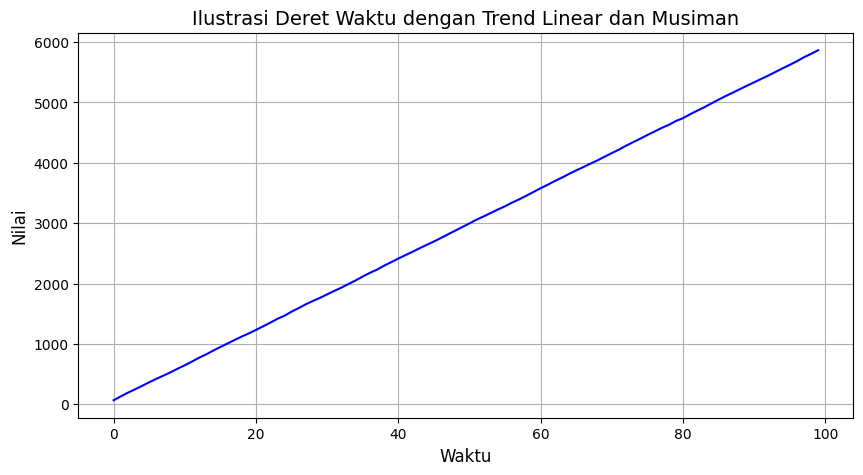

In [60]:
plt.figure(figsize=(10, 5))
plt.plot(x, series, color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman', fontsize=14)
plt.grid()
plt.show()

**Untuk deret tersebut, dibutuhkan model yang mampu menangkap kecenderungan linear (tren) sekaligus kecenderungan musiman dalam deret. Salah satu model sederhana yang dapat digunakan adalah model regresi linear dengan variabel musiman.**

Berdasarkan pola deret waktu yang terbentuk, data menunjukkan adanya  kecenderungan tren linear positif dan pola musiman berulang setiap 12 periode. Oleh karena itu, model yang digunakan adalah regresi linear dengan variabel musiman, dengan bentuk umum:

$$
Y_t = \beta_0 + \beta_1 t + \beta_2 X_1 + \beta_3 X_2 + ... + \beta_k X_k + e_t
$$

Keterangan:

- $\beta_0$ = intersep atau nilai dasar dari deret waktu.
- $\beta_1 t$ = komponen tren linear yang menunjukkan perubahan nilai berdasarkan waktu.
- $X_1, X_2, ..., X_k$ = variabel dummy musiman yang digunakan untuk menangkap pola musiman.
- $e_t$ = error atau noise acak dalam data.

Model ini dipilih karena mampu menangkap dua karakteristik utama deret, yaitu peningkatan nilai dalam jangka panjang akibat tren linear dan variasi berulang akibat komponen musiman.

In [62]:
# mengubah data menjadi format dataframe
df_mix = pd.DataFrame(series, columns=['Value'])

# mengekstrak komponen musiman dalam data
from statsmodels.tsa.deterministic import Seasonality
season= Seasonality(12, initial_period=1).in_sample(df_mix.index)
season.columns=['Januari','Februari','Maret','April','Mei','Juni','Juli','Agustus','September','Oktober','November','Desember']

In [63]:
season['period']=x

model_mix=sm.OLS(series,season).fit()

In [64]:
print(model_mix.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 5.025e+06
Date:                Fri, 04 Sep 2026   Prob (F-statistic):          1.52e-248
Time:                        16:13:08   Log-Likelihood:                -212.62
No. Observations:                 100   AIC:                             451.2
Df Residuals:                      87   BIC:                             485.1
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Januari       68.1802      0.810     84.126      0.0

**Bagaimana cara menginterpretasikan nilai koefisien regresi yang diperoleh dalam model regresi tersebut?**

Model regresi yang terbentuk:

$$
Y_t = \beta_{bulan} + \beta_1(period) + e_t
$$

Berdasarkan hasil regresi, nilai koefisien period = 58,5053 menunjukkan bahwa setiap kenaikan 1 periode waktu akan meningkatkan nilai deret sebesar 58,5053 unit. Hal ini menunjukkan adanya tren linear positif yang kuat pada data.

Koefisien pada variabel bulan menunjukkan pola musiman. Nilai koefisien masing-masing bulan menggambarkan rata-rata nilai deret pada periode tersebut. Contohnya:


*   Bulan April memiliki nilai koefisien sebesar 73,0406, menunjukkan nilai relatif paling tinggi dibandingkan bulan lainnya.
*   Bulan September memiliki nilai koefisien sebesar 62,7293, menunjukkan nilai relatif lebih rendah dibandingkan periode lain.


Secara keseluruhan, koefisien bulan menunjukkan adanya fluktuasi musiman, sedangkan koefisien periode menunjukkan adanya peningkatan nilai akibat tren waktu. Model ini mampu menangkap kombinasi antara tren linear dan pola musiman pada deret waktu.





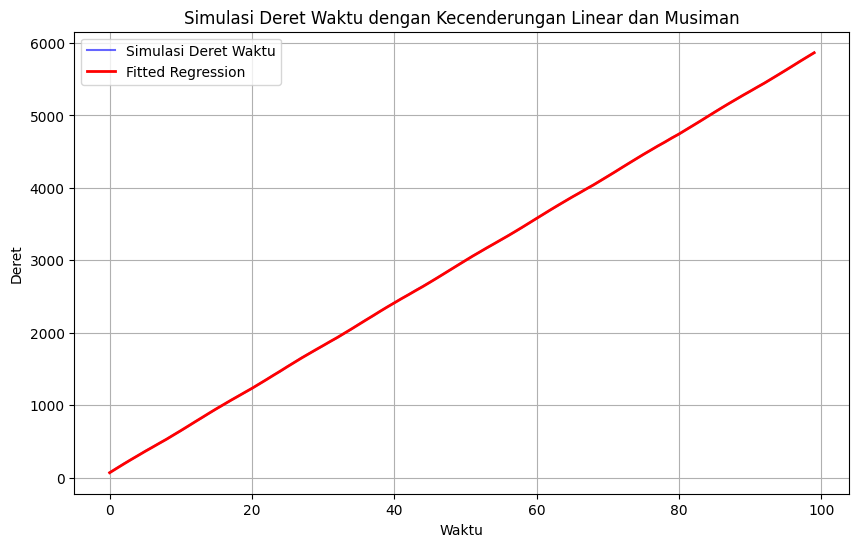

In [65]:
# Prediksi menggunakan model yang sudah dilatih
pred_mix = model_mix.predict(season)

# Plot hasil simulasi deret waktu dan regresi kuadratik
plt.figure(figsize=(10, 6))
plt.plot(x, series, label='Simulasi Deret Waktu', color='blue', alpha=0.6)
plt.plot(x, pred_mix, label='Fitted Regression', color='red', linewidth=2)
plt.title('Simulasi Deret Waktu dengan Kecenderungan Linear dan Musiman')
plt.xlabel('Waktu')
plt.ylabel('Deret')
plt.legend()
plt.grid(True)
plt.show()

Berdasarkan grafik hasil pengepasan model, garis regresi (merah) hampir mengikuti pola data simulasi (biru). Hal ini menunjukkan bahwa model mampu menangkap komponen tren linear dan musiman dengan baik.

Jika hasil pengujian residual menunjukkan p-value lebih besar dari 0,05 pada seluruh uji, maka dapat disimpulkan bahwa tidak terdapat pelanggaran asumsi regresi. Dengan demikian, model regresi linear dengan variabel musiman sudah sesuai untuk menggambarkan pola deret waktu tersebut.

**Lakukan pengecekan asumsi model! Jelaskan apakah hasil menunjukkan ada pelanggaran asumsi dalam model!**

In [66]:
# Uji asumsi model

import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan, acorr_ljungbox
import statsmodels.api as sm

# Mengambil residual model
residuals = model.resid


# 1. Uji Normalitas Residual (Shapiro-Wilk)

shapiro_stat, shapiro_p = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test ===")
print("Statistic :", shapiro_stat)
print("P-value   :", shapiro_p)


# 2. Uji Heteroskedastisitas (Breusch-Pagan)

bp_test = het_breuschpagan(
    residuals,
    model.model.exog
)

print("\n=== Breusch-Pagan Test ===")
print("LM Statistic :", bp_test[0])
print("P-value      :", bp_test[1])


# 3. Uji Autokorelasi (Ljung-Box)

ljung_test = acorr_ljungbox(
    residuals,
    lags=[12],
    return_df=True
)

print("\n=== Ljung-Box Test ===")
print(ljung_test)

=== Shapiro-Wilk Test ===
Statistic : 0.9942433812259206
P-value   : 0.9505380764047506

=== Breusch-Pagan Test ===
LM Statistic : 0.3700373145365421
P-value      : 0.5429839292237495

=== Ljung-Box Test ===
      lb_stat  lb_pvalue
12  23.626439   0.022855


**Kesimpulan Uji Asumsi Model Regresi Linear dengan Variabel Musiman:**

Berdasarkan hasil pengujian asumsi model diperoleh:
1. Uji Normalitas Residual (Shapiro-Wilk)
Hasil uji menunjukkan p-value = 0,9505 > 0,05, sehingga residual berdistribusi normal.
2. Uji Heteroskedastisitas (Breusch-Pagan)
Hasil uji menunjukkan p-value = 0,5430 > 0,05, sehingga tidak terdapat masalah heteroskedastisitas dan varians residual dapat dianggap konstan.
3. Uji Autokorelasi (Ljung-Box)
Hasil uji menunjukkan p-value = 0,0229 < 0,05, sehingga terdapat indikasi autokorelasi pada residual.

**KESIMPULAN:**

Model sudah memenuhi asumsi normalitas dan homoskedastisitas, tetapi masih terdapat pelanggaran asumsi autokorelasi. Artinya, residual masih memiliki hubungan antar waktu sehingga model belum sepenuhnya menangkap pola ketergantungan waktu pada data.

**Saat melihat plot dari suatu deret, terkadang kita tidak yakin komponen apa saja yang ada dalam deret. Misalkan, apakah deret tidak memuat tren? apakah ada tren? apakah ada komponen musiman? Untuk memastikan komponen apa saja yang ada dalam suatu deret, dapat dilakukan dengan dekomposisi deret. Dekomposisi deret bertujuan menguraikan deret menjadi 3 komponen, yaitu tren, musiman, dan noise.**

### Dekomposisi Deret Waktu

Dalam analisis deret waktu, terkadang pola data tidak dapat diketahui hanya melalui visualisasi grafik. Oleh karena itu, diperlukan metodedekomposisi deret waktu untuk mengidentifikasi komponen-komponen yang terdapat dalam data.

Dekomposisi deret waktu bertujuan untuk memisahkan deret menjadi tiga komponen utama, yaitu:

1. Komponen Tren (Trend)  
   Menunjukkan pola pergerakan jangka panjang dalam data, seperti peningkatan atau penurunan nilai secara bertahap.

2. Komponen Musiman (Seasonality)
   Menunjukkan pola berulang dalam periode tertentu, misalnya pola bulanan, kuartalan, atau tahunan.

3. Komponen Noise/Residual
   Merupakan variasi acak dalam data yang tidak dapat dijelaskan oleh tren maupun pola musiman.

Secara umum, dekomposisi deret waktu dapat dituliskan sebagai:

$$
Y_t = T_t + S_t + N_t
$$

dengan:
- $Y_t$ = nilai deret waktu pada periode ke-$t$
- $T_t$ = komponen tren
- $S_t$ = komponen musiman
- $N_t$ = komponen noise

Melalui dekomposisi, dapat diketahui apakah suatu deret memiliki tren, pola musiman, atau hanya dipengaruhi oleh variasi acak.

In [67]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear
from statsmodels.tsa.seasonal import seasonal_decompose
result = seasonal_decompose(df['Value'], model='additive', period=12)

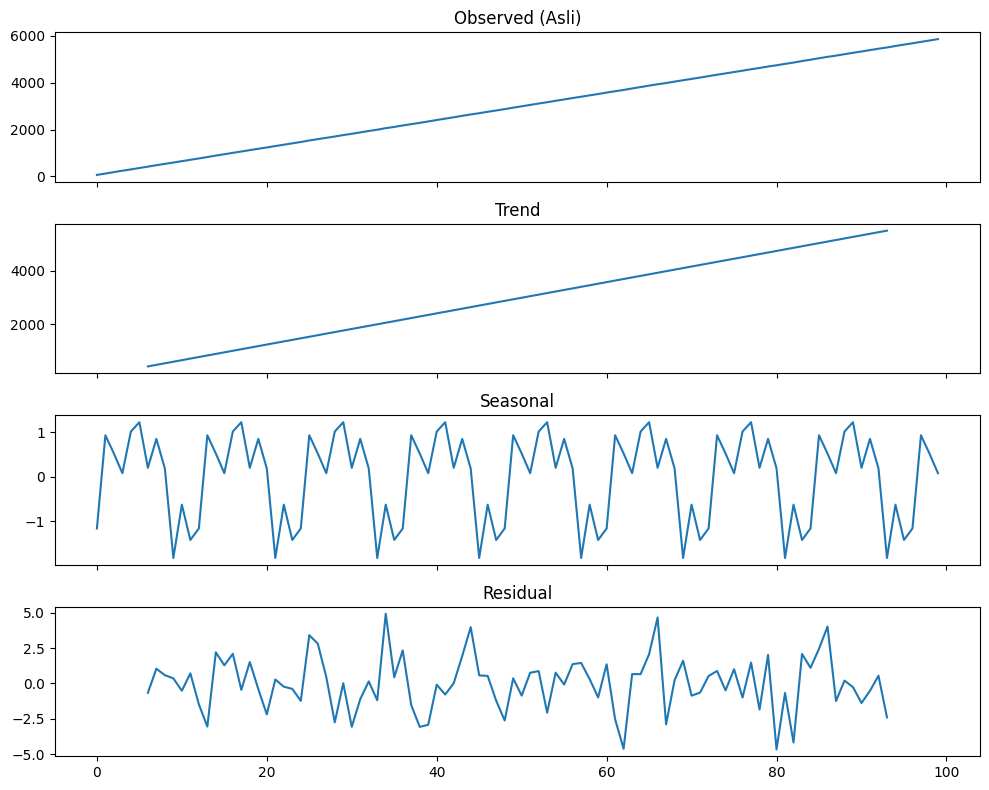

In [68]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama, yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
Komponen tren menunjukkan pola peningkatan linear yang kuat dari waktu ke waktu. Hal ini menunjukkan bahwa nilai deret mengalami kenaikan secara konsisten dalam jangka panjang.
2. Komponen Musiman (Seasonal)
Komponen musiman menunjukkan adanya pola berulang secara periodik. Fluktuasi naik dan turun terjadi secara konsisten pada periode tertentu, sehingga menunjukkan adanya pengaruh musiman dalam data.
3. Komponen Residual (Noise)
Komponen residual menunjukkan variasi acak yang tersisa setelah pengaruh tren dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol tanpa pola tertentu, sehingga menunjukkan bahwa sebagian besar pola data telah berhasil dijelaskan oleh komponen tren dan musiman.

**KESIMPULAN:**

Hasil dekomposisi menunjukkan bahwa deret memiliki tren meningkat yang dominan dan pola musiman yang berulang, sedangkan komponen noise relatif kecil. Dengan demikian, model yang mempertimbangkan komponen tren dan musiman sudah sesuai untuk menggambarkan karakteristik data.

In [70]:
# Melakukan dekomposisi untuk deret simulasi kecenderungan linear dan musiman
from statsmodels.tsa.seasonal import seasonal_decompose
result_mix = seasonal_decompose(df_mix['Value'], model='additive', period=12)

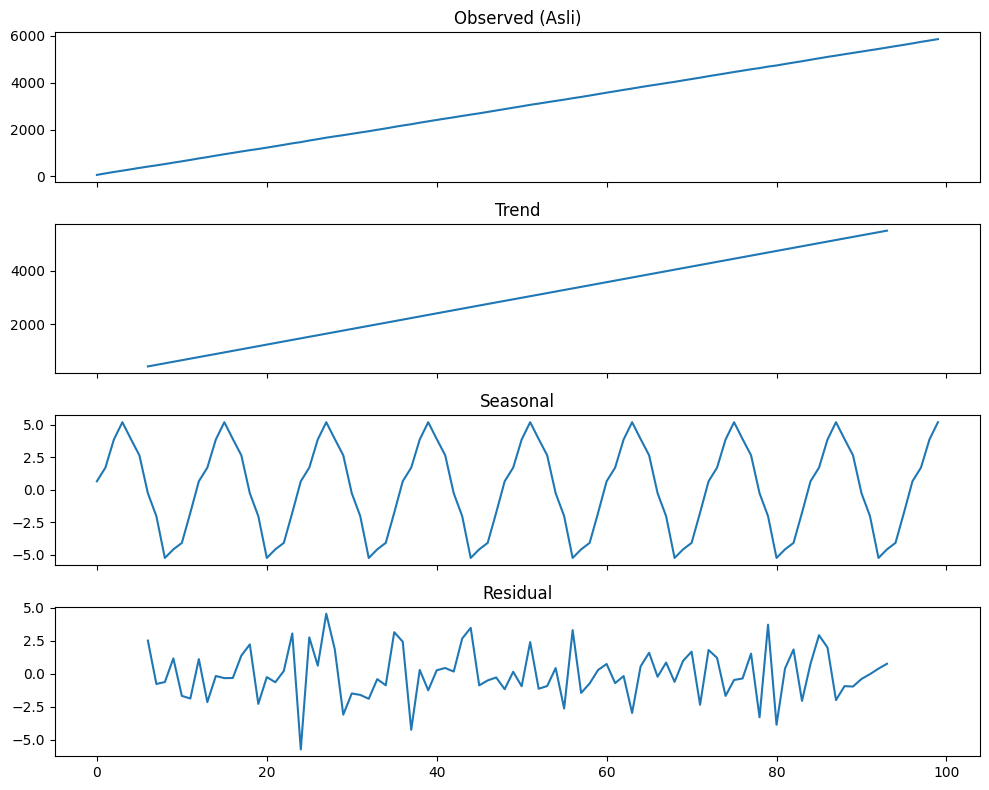

In [71]:
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)

result_mix.observed.plot(ax=axes[0], title='Observed (Asli)')
result_mix.trend.plot(ax=axes[1], title='Trend')
result_mix.seasonal.plot(ax=axes[2], title='Seasonal')
result_mix.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()


**Bagaimana interpretasi hasil dekomposisi deret tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
Komponen tren menunjukkan adanya peningkatan linear yang kuat dari waktu ke waktu. Hal ini menunjukkan bahwa nilai deret mengalami kenaikan secara konsisten dalam jangka panjang.
2. Komponen Musiman (Seasonal)
Komponen musiman menunjukkan pola berulang secara periodik dengan periode tertentu. Pola naik dan turun terlihat stabil pada setiap siklus, sehingga terdapat pengaruh musiman pada data.
3. Komponen Residual (Noise)
Komponen residual menunjukkan variasi acak yang tersisa setelah komponen tren dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu, sehingga sebagian besar informasi data sudah dijelaskan oleh model.

Berdasarkan pola data, model dekomposisi yang sesuai adalah model aditif, karena amplitudo komponen musiman terlihat relatif konstan sepanjang waktu dan tidak mengalami peningkatan seiring bertambahnya nilai tren.

Secara umum, deret memiliki tren meningkat, pola musiman yang stabil, dan noise acak dengan variasi kecil, sehingga model aditif lebih tepat digunakan untuk menggambarkan struktur data.

**Ketika melakukan dekoposisi deret, perlu diperhatikan bahwa terdapat 2 jenis model untuk dekomposisi, yaitu model `Aditif` dan `multiplikatif`.**

- Model `aditif` digunakan jika ragam deret relatif konstan atau kecil

- Model `multiplikatif` digunakan jika ragam deret besar

In [72]:
# ilustrasi untuk deret multiplikatif
# Parameter
np.random.seed(22025)
n = 100  # Jumlah titik data
x = np.arange(n)

# Komponen trend linear
a, b = 0.05, 10 #(intersep dan slope)
trend = a * x + b

# Komponen musiman (sinusoidal)
seasonality = 1+ 0.5 * np.sin(2 * np.pi * x / 12)

# Noise acak
noise = np.random.normal(scale=0.2, size=n)

# Gabungan semua komponen
series_multi = trend*seasonality + noise

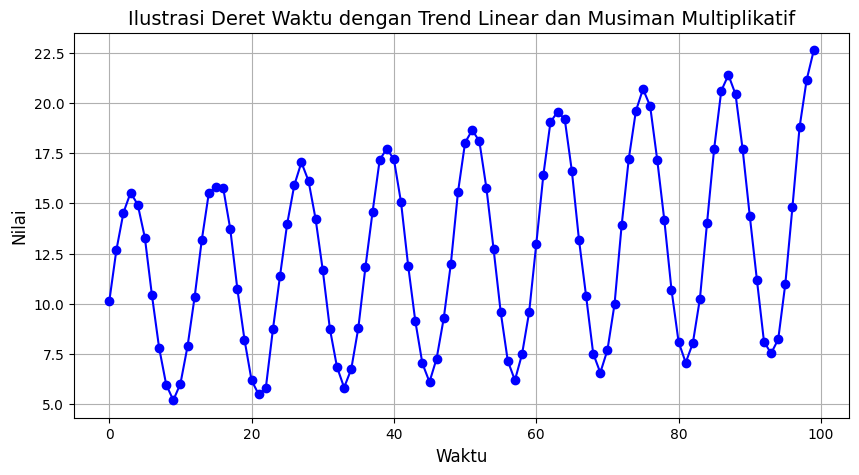

In [73]:
plt.figure(figsize=(10, 5))
plt.plot(x, series_multi, color='b', marker='o')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu dengan Trend Linear dan Musiman Multiplikatif', fontsize=14)
plt.grid()
plt.show()

**Dekomposisi dengan model multiplikatif hanya bisa dilakukan untuk deret dengan nilai >0, sehingga jika deret memiliki nilai 0 atau negatif maka deret perlu ditransformasi.**

Berdasarkan grafik, deret waktu menunjukkan adanya Tren meningkat yang disertai dengan pola musiman yang berulang. Nilai deret mengalami kenaikan dari waktu ke waktu, sementara pola naik dan turun tetap terjadi pada setiap periode.

Pada model multiplikatif, deret waktu dapat dituliskan sebagai:

$$
Y_t = T_t \times S_t \times N_t
$$

dengan:

- $Y_t$ = nilai deret waktu pada periode ke-$t$
- $T_t$ = komponen tren
- $S_t$ = komponen musiman
- $N_t$ = komponen noise/residual

Model multiplikatif digunakan karena besar fluktuasi musiman berubah mengikuti peningkatan tren. Artinya, variasi musiman tidak bersifat konstan, tetapi meningkat secara proporsional terhadap nilai deret.

Karena seluruh nilai pada deret bernilai positif, maka dekomposisi multiplikatif dapat diterapkan tanpa melakukan transformasi data terlebih dahulu.

Secara umum, model multiplikatif sesuai digunakan untuk menggambarkan deret yang memiliki **tren meningkat dengan pola musiman yang amplitudonya mengikuti perubahan level data**.

In [74]:
#  Dekomposisi dengan model multiplikatif
# mengubah data menjadi format dataframe
df_multi = pd.DataFrame(series_multi, columns=['Value'])

from statsmodels.tsa.seasonal import seasonal_decompose
result_multi = seasonal_decompose(df_multi['Value'], model='multiplicative', period=12)

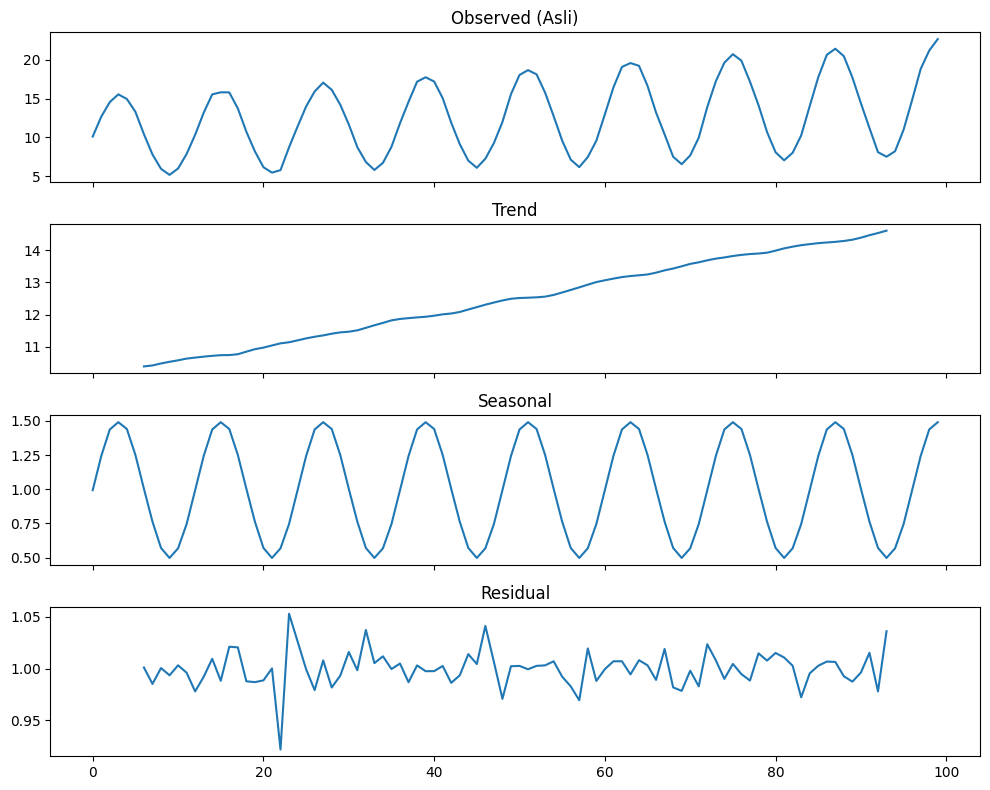

In [75]:
# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result_multi.observed.plot(ax=axes[0], title='Observed (Asli)')
result_multi.trend.plot(ax=axes[1], title='Trend')
result_multi.seasonal.plot(ax=axes[2], title='Seasonal')
result_multi.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana Anda menginterpretasikan plot hasil dekomposisi tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari tiga komponen utama yaitu tren, musiman, dan residual.
1. Komponen Tren (Trend)
Komponen tren menunjukkan adanya peningkatan secara bertahap dari waktu ke waktu. Hal ini menunjukkan bahwa nilai deret mengalami pertumbuhan jangka panjang.
2. Komponen Musiman (Seasonal)
Komponen musiman menunjukkan pola berulang secara periodik dengan amplitudo yang relatif konstan. Pola naik dan turun terjadi secara konsisten pada setiap periode, sehingga menunjukkan adanya pengaruh musiman.
3. Komponen Residual (Noise)
Komponen residual menunjukkan variasi acak yang tersisa setelah komponen tren dan musiman dipisahkan. Nilai residual berada di sekitar angka 1 dan tidak menunjukkan pola tertentu, sehingga sebagian besar pola data sudah dapat dijelaskan oleh tren dan musiman.

Berdasarkan karakteristik tersebut, model dekomposisi yang sesuai adalah model multiplikatif, karena variasi musiman berubah mengikuti peningkatan nilai tren dan data memiliki nilai positif.

Secara umum, deret ini memiliki tren meningkat, pola musiman yang stabil secara proporsional, dan noise yang relatif kecil.

In [80]:
# Parameter
np.random.seed(51058)
n = 100  # Jumlah titik data
x = np.arange(n)

# Hanya noise acak tanpa trend atau musiman
noise = np.random.normal(loc=10, scale=2, size=n)  # Nilai acak sekitar 10

# Buat DataFrame untuk regresi
df = pd.DataFrame({'Time': x, 'Series': noise})
df['Time'] = pd.to_datetime(df['Time'], unit='D')  # Konversi ke format waktu
df.set_index('Time', inplace=True)

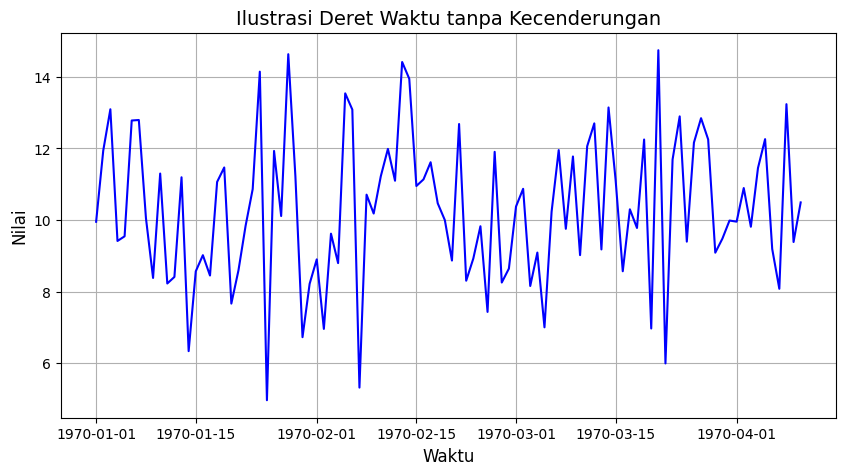

In [81]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Series'], color='b')
plt.xlabel('Waktu', fontsize=12)
plt.ylabel('Nilai', fontsize=12)
plt.title('Ilustrasi Deret Waktu tanpa Kecenderungan', fontsize=14)
plt.grid()
plt.show()

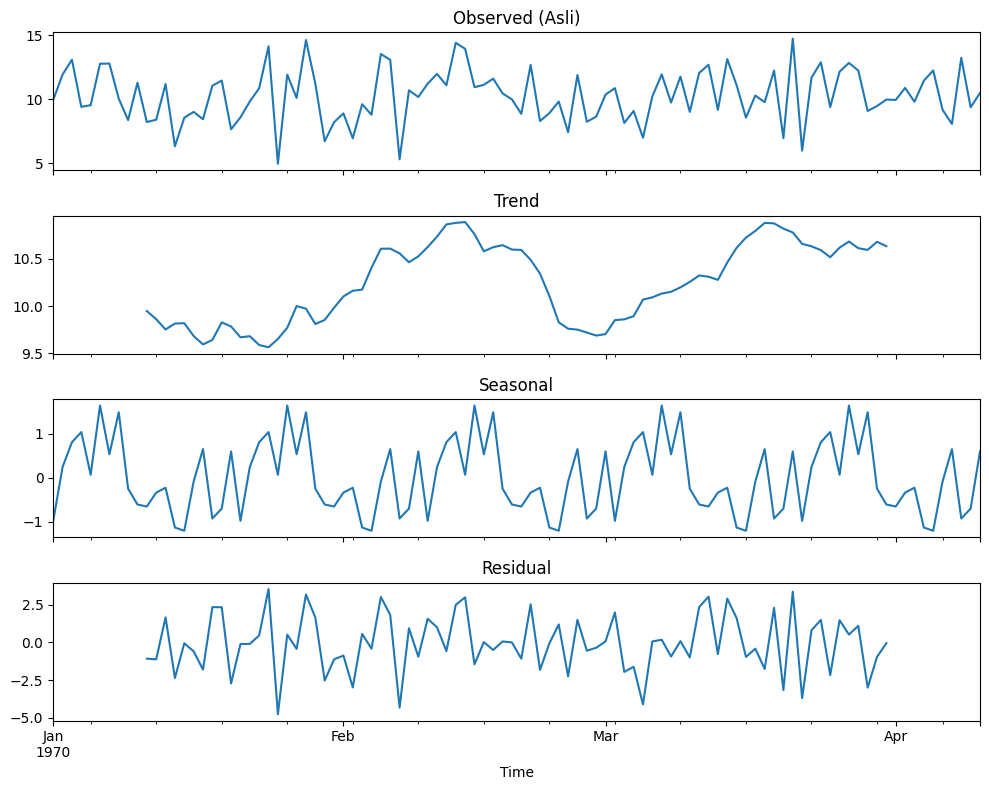

In [82]:
# Lakukan dekomposisi dengan model aditif
result = seasonal_decompose(df['Series'], model='additive', period=20)

# Plot hasil dekomposisi
fig, axes = plt.subplots(4, 1, figsize=(10, 8), sharex=True)
result.observed.plot(ax=axes[0], title='Observed (Asli)')
result.trend.plot(ax=axes[1], title='Trend')
result.seasonal.plot(ax=axes[2], title='Seasonal')
result.resid.plot(ax=axes[3], title='Residual')

plt.tight_layout()
plt.show()

**Bagaimana interpretasi dari plot tersebut?**

Berdasarkan hasil dekomposisi, deret waktu terdiri dari beberapa komponen yaitu observed (data asli), tren, musiman, dan residual.

1. Komponen Tren (Trend)
menunjukkan pola naik dan turun secara perlahan tanpa adanya kecenderungan peningkatan atau penurunan yang sangat kuat. Hal ini menunjukkan bahwa perubahan jangka panjang dalam data relatif kecil.
2. Komponen Musiman (Seasonal)
 menunjukkan adanya pola berulang secara periodik. Fluktuasi naik dan turun muncul secara konsisten pada periode tertentu, sehingga menunjukkan adanya pengaruh musiman dalam data.
 3. Komponen Residual (Noise)
menunjukkan variasi acak yang tersisa setelah tren dan musiman dihilangkan. Residual berfluktuasi di sekitar nilai nol dan tidak menunjukkan pola tertentu, sehingga sebagian besar pola data sudah dijelaskan oleh komponen tren dan musiman.

**Kesimpulan:**

Hasil dekomposisi menunjukkan bahwa data memiliki pola musiman yang cukup jelas, sedangkan komponen tren relatif lemah. Variasi data lebih banyak dipengaruhi oleh pola musiman dan noise acak. Model dekomposisi yang sesuai dapat ditentukan berdasarkan kestabilan amplitudo musiman pada data.